In [195]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [196]:
# Configuration du notebook
EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS)  # Doit être 19
MODEL_NAME  = 'model_california_hybrid'

In [197]:
class MCTFeatureExtractor(nn.Module):
    def __init__(self, in_channels):
        super(MCTFeatureExtractor, self).__init__()
        # Branche 1: Échelle fine (kernel 3)
        self.branch1 = nn.Sequential(
            nn.Conv1d(in_channels, 42, kernel_size=3, padding=1),
            nn.BatchNorm1d(42),
            nn.ReLU()
        )
        # Branche 2: Échelle moyenne (kernel 5)
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_channels, 43, kernel_size=5, padding=2),
            nn.BatchNorm1d(43),
            nn.ReLU()
        )
        # Branche 3: Échelle large (kernel 7)
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, 43, kernel_size=7, padding=3),
            nn.BatchNorm1d(43),
            nn.ReLU()
        )
        # Total filtres concaténés : 42 + 43 + 43 = 128

    def forward(self, x):
        x = x.transpose(1, 2) # [B, C, T]
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        # Concaténation sur la dimension des channels
        out = torch.cat([x1, x2, x3], dim=1) 
        return out.transpose(1, 2) # [B, T, 128]


class BiGRUProcessor(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128):
        super(BiGRUProcessor, self).__init__()
        # Stacked Bi-GRU : 128 units puis 64 units
        self.gru1 = nn.GRU(input_dim, 128, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(256, 64, batch_first=True, bidirectional=True)
        # Sortie finale : 64 * 2 (bidir) = 128
        
    def forward(self, x):
        # x shape: [B, 18, 64]
        out, _ = self.gru1(x)  # out: [B, 18, 256]
        out, _ = self.gru2(out) # out: [B, 18, 128]
        return out
    


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim=128):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [B, T_reduced, 128]
        # 1. Calcul des scores (énergie)
        energy = self.attn(x) # [B, 18, 1]
        
        # 2. Normalisation Softmax
        weights = torch.softmax(energy, dim=1)
        
        # 3. Somme pondérée (contexte)
        context = torch.sum(weights * x, dim=1) # [B, 128]
        return context, weights
    



class MCTHybridNet(nn.Module):
    def __init__(self, num_classes=6, in_channels=19):
        super(MCTHybridNet, self).__init__()
        # 1. Extraction Multi-échelle (Sortie: 128)
        self.feature_extractor = MCTFeatureExtractor(in_channels)
        
        # 2. Processeur Bi-GRU (Sortie: 128 car le dernier GRU est bidir 64)
        self.sequence_processor = BiGRUProcessor(input_dim=128, hidden_dim=128)
        
        # 3. Attention (Prend 128, sort 128)
        self.attention = TemporalAttention(hidden_dim=128)
        
        # 4. Classifieur (CORRECTIF ICI : l'entrée est 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),  # Changé de 256 à 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)  
        x = self.sequence_processor(x) 
        context, weights = self.attention(x)
        logits = self.classifier(context)
        return logits, weights

In [198]:
df_cali = pd.read_csv('../data/california_preprocessed_v2.csv')
df_cali.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.04820,0.06105,0.06470,0.09330,0.13855,0.15165,0.17355,0.17550,0.21355,0.15090,...,0.00000,0.00000,0.00000,0.397416,-0.651279,0.525297,-0.433458,-0.330163,76,4
1,0.06170,0.08805,0.10080,0.13435,0.19605,0.21765,0.23495,0.23375,0.27285,0.23035,...,0.00000,0.00000,0.00000,0.132386,1.235055,0.525297,-0.583178,-0.612763,36,2
2,0.04420,0.06350,0.10130,0.11880,0.13210,0.15020,0.17570,0.18160,0.24420,0.20890,...,0.41005,0.29705,0.24475,-1.015309,0.950606,0.525297,-0.266627,-0.443951,69,0
3,0.08615,0.10970,0.14635,0.16965,0.18835,0.20460,0.22510,0.23185,0.33110,0.25865,...,0.00000,0.00000,0.00000,-1.032278,1.098399,0.525297,-0.561790,-0.781662,36,2
4,0.24455,0.24090,0.25870,0.27515,0.27545,0.28775,0.30590,0.30050,0.38235,0.33175,...,0.00000,0.00000,0.00000,0.049402,1.259696,1.146951,-0.608845,-0.512391,36,2


In [199]:
mapping = {69: 0, 3: 1, 36: 2, 75: 3, 76: 4, 176: 5}
def map_classes(val):
    return mapping.get(val, 5)

df_cali['target_class'] = df_cali['cropland'].apply(map_classes)

targets = {0: 2054, 1: 2037, 2: 974, 3: 783, 4: 640, 5: 3512}
sampled_dfs = []
for class_id, count in targets.items():
    sub_df = df_cali[df_cali['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_cali_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_cali_final['target_class'].value_counts())

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64


In [200]:
print(df_cali['target_class'].value_counts())
print(f"Total : {len(df_cali)}")

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64
Total : 10000


In [201]:
def prepare_mixed_hybrid_data(df, extra_cols):
    """
    Prépare les données en mode 'Mixte' (14 spectrales + 5 environnementales).
    Total features par date : 19
    Format de sortie : [Batch, 36, 19]
    """
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    
    # 1. Calcul des indices (Ton bloc actuel)
    for i in range(36):
        b3, b4, b5, b8 = df[f'd{i}_B3'], df[f'd{i}_B4'], df[f'd{i}_B5'], df[f'd{i}_B8']
        df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
        df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
        df[f'd{i}_LCI']   = (b8 - b5) / (b8 + b4 + 1e-8)
        df[f'd{i}_GNDVI'] = (b8 - b3) / (b8 + b3 + 1e-8)

    # 2. Extraction des 14 features spectrales
    PURE_FEATURES = BANDS + ['NDVI', 'NDRE', 'LCI', 'GNDVI']
    ordered_cols = [f'd{i}_{feat}' for i in range(36) for feat in PURE_FEATURES]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 14)
    
    # 3. Intégration des 5 EXTRA_COLS (Mode Contextuel)
    if extra_cols and len(extra_cols) > 0:
        # On prend les colonnes statiques (ex: elevation, soil_texture)
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
        # On les "étire" sur les 36 dates : [Batch, 5] -> [Batch, 36, 5]
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        # Fusion : [Batch, 36, 14 + 5] = [Batch, 36, 19]
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, y

# --- Utilisation ---
EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS) # 19

x_cal, y_cal = prepare_mixed_hybrid_data(df_cali_final, EXTRA_COLS)

print(f'Nouveau Shape X: {x_cal.shape}') # Doit être [Batch, 36, 19]

Nouveau Shape X: torch.Size([10000, 36, 19])


/tmp/ipykernel_8384/1529731693.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
/tmp/ipykernel_8384/1529731693.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
/tmp/ipykernel_8384/1529731693.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

In [202]:
# Split simplifié (sans les masques)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_cal, y_cal, test_size=0.18, stratify=y_cal, random_state=96
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=96
)

# Loaders propres
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val),   batch_size=256)
test_loader  = DataLoader(TensorDataset(x_test, y_test),  batch_size=256)

In [203]:
import copy
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 50 # On augmente un peu car le scheduler va prolonger l'apprentissage efficace
best_f1 = 0.0

# 1. Instanciation (MCTHybridNet avec 19 canaux)
model = MCTHybridNet(num_classes=6, in_channels=19).to(device)

# 2. Gestion du déséquilibre : On booste les Almonds (Index 3)
# [Grapes, Rice, Alfalfa, Almonds, Pistachios, Others]
weights = torch.tensor([1.0, 1.0, 1.0, 3.5, 2.0, 0.8]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

# 3. Optimizer & Scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
# On réduit le LR de moitié si le F1-macro ne monte plus pendant 5 époques
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    
    for b_x, b_y in pbar:
        b_x, b_y = b_x.to(device), b_y.to(device)
        optimizer.zero_grad()
        outputs, _ = model(b_x) 
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.6f}')

    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for b_x, b_y in val_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            outputs, _ = model(b_x)
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    # Calcul des métriques
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    
    # MISE À JOUR DU SCHEDULER basée sur le F1-Score macro
    scheduler.step(f1)
    
    print(f'\n[Val] Acc: {val_acc:.2f}% | F1-Macro: {f1:.4f} | LR: {optimizer.param_groups[0]["lr"]}')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'🔥 Nouveau record ! F1: {best_f1:.4f}')

model.load_state_dict(best_model_state)

Époque 1/50: 100%|██████████| 33/33 [00:00<00:00, 49.00batch/s, loss=1.2948, lr=0.001000]



[Val] Acc: 71.11% | F1-Macro: 0.5779 | LR: 0.001
🔥 Nouveau record ! F1: 0.5779


Époque 2/50: 100%|██████████| 33/33 [00:00<00:00, 109.03batch/s, loss=0.9405, lr=0.001000]



[Val] Acc: 76.11% | F1-Macro: 0.6981 | LR: 0.001
🔥 Nouveau record ! F1: 0.6981


Époque 3/50: 100%|██████████| 33/33 [00:00<00:00, 105.16batch/s, loss=0.0797, lr=0.001000]


...

Époque 49/50: 100%|██████████| 33/33 [00:00<00:00, 119.58batch/s, loss=1.1417, lr=0.000063]



[Val] Acc: 89.72% | F1-Macro: 0.8477 | LR: 6.25e-05


Époque 50/50: 100%|██████████| 33/33 [00:00<00:00, 117.02batch/s, loss=0.5800, lr=0.000063]



[Val] Acc: 90.28% | F1-Macro: 0.8568 | LR: 6.25e-05


<All keys matched successfully>

In [204]:
torch.save(model.state_dict(), f'models/model_california_hybrid.pth')
print('Modèle sauvegardé : model_california_hybrid.pth')

Modèle sauvegardé : model_california_hybrid.pth


=== Test Set - HybridCropNet ===
OA    : 0.8944
Kappa : 0.8642
              precision    recall  f1-score   support

      Grapes       0.90      0.78      0.83       296
        Rice       0.99      0.99      0.99       293
     Alfalfa       0.87      0.81      0.84       140
     Almonds       0.60      0.78      0.68       113
  Pistachios       0.69      0.83      0.75        92
      Others       0.97      0.97      0.97       506

    accuracy                           0.89      1440
   macro avg       0.84      0.86      0.84      1440
weighted avg       0.90      0.89      0.90      1440



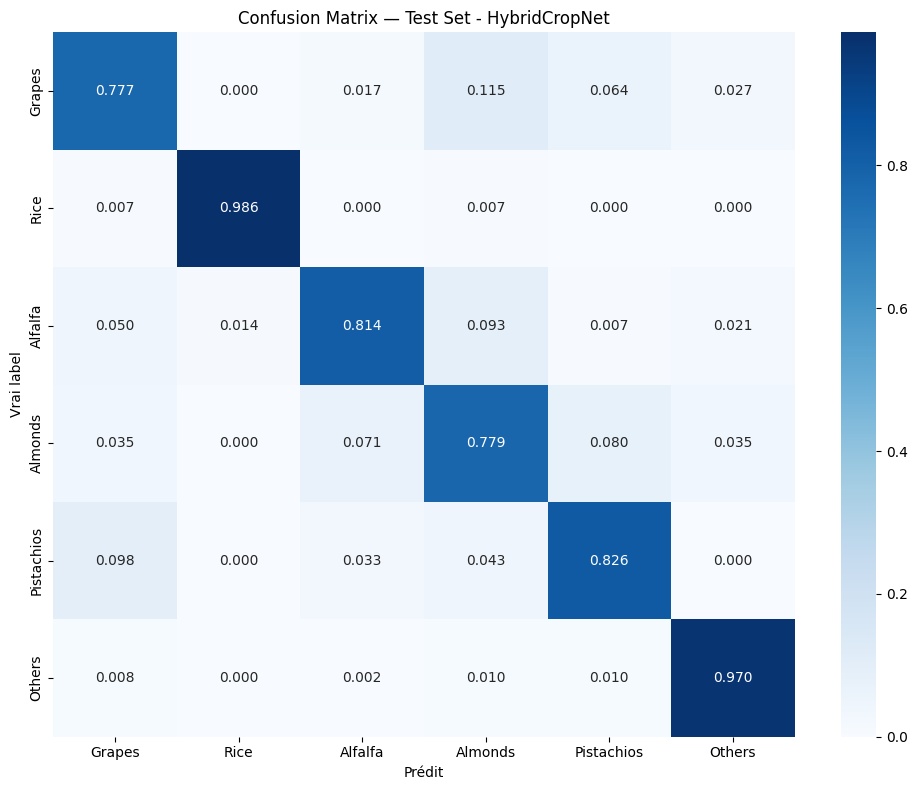

In [205]:
def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        # 1. On unpack seulement 2 valeurs (X et Y)
        for b_x, b_y in test_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            # 2. On unpack les 2 sorties du nouveau modèle (logits et weights)
            outputs, _ = model(b_x) 
            
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
            
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calcul des métriques globales
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    
    # Rapport détaillé par classe (c'est là qu'on verra le score des Amandes !)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    
    # Sauvegarde
    os.makedirs('./figs', exist_ok=True)
    plt.savefig(f'./figs/HybridNet_confusion_matrix.png', dpi=150)
    plt.show()


class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
evaluate_on_test(model, test_loader, class_names, title='Test Set - HybridCropNet')